In [1]:
from IPython.display import Video
import cv2
import numpy as np
import os
from IPython.display import HTML
from base64 import b64encode

from PIL import Image

import cv2
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML


from skimage.segmentation import slic
from skimage.color import rgb2lab
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans

(600, 600, 3) uint8 0 255
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 

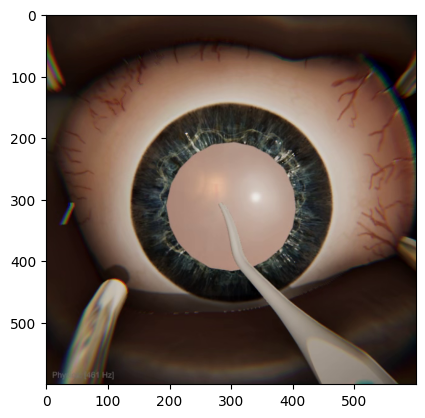

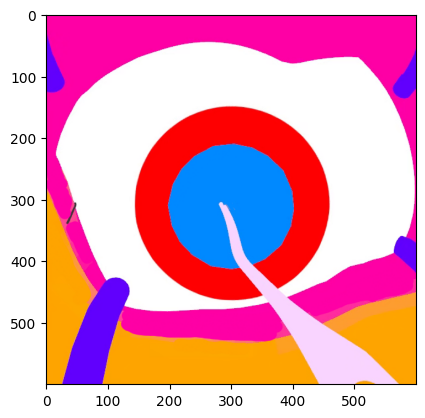

(600, 600) uint8
[0 1 2 3 4 5 6]
[ 30480  50037 119171  83483  14319  45409  17101]
0
(600, 600)
1
(600, 600)
2
(600, 600)
3
(600, 600)
4
(600, 600)
5
(600, 600)
6
(600, 600)


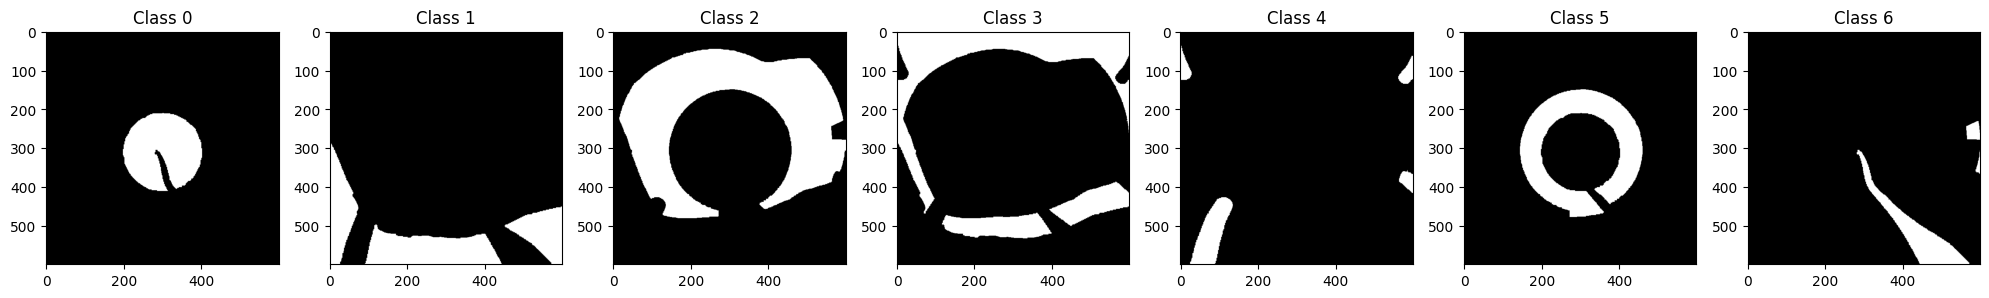

In [2]:



img1 = Image.open("records_cadis_1/records_single_files/r2/frame_0043.png")
img2 = Image.open("records_cadis_1/records_single_files/r2_processed/mask_0043_p.png")

img1 = np.asarray(img1)
img2 = np.asarray(img2)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


print(img2.shape, img2.dtype, np.min(img2), np.max(img2))


rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(img2, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)
print(img2[50,50])

# rgb_mask = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# rgb_mask = img2[:,:,0]
# rgb_mask = img2
# print(rgb_mask.shape, rgb_mask.dtype, np.min(rgb_mask), np.max(rgb_mask))



# rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(rgb_mask, return_counts=True)
# print(rgb_mask_unique_values)
# print(rgb_mask_unique_counts)
# print(rgb_mask[50,50])



plt.imshow(img1, cmap = "gray")
plt.show()


plt.imshow(img2, cmap = "gray")
plt.show()





lab = rgb2lab(img2)

segments = slic(img2, n_segments=300, compactness=10, start_label=0)

# Compute mean color per segment
segment_colors = []
for seg_id in np.unique(segments):
    segment_colors.append(lab[segments == seg_id].mean(axis=0))

segment_colors = np.array(segment_colors)

# Cluster segments
kmeans = KMeans(n_clusters=7, random_state=0)
seg_labels = kmeans.fit_predict(segment_colors)

# Build label map
label_map = np.zeros(segments.shape, dtype=np.int32)
for seg_id, lbl in enumerate(seg_labels):
    label_map[segments == seg_id] = lbl


kernel = np.ones((5,5), np.uint8)
label_map = cv2.morphologyEx(label_map.astype(np.uint8),
                          cv2.MORPH_OPEN, kernel)

print(label_map.shape, label_map.dtype)
rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(label_map, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)

seg_labels = rgb_mask_unique_values
fig, axes = plt.subplots(1, len(seg_labels),  figsize=(20, 7))


for i, cls_ in enumerate(seg_labels, start=0):
    print(cls_)
    # Create binary mask for this class
    binary_mask = np.where(label_map == cls_, 1, 0)
    print(binary_mask.shape)
    # print(np.unique(label_map, return_counts=True))

    # Show in subplot
    axes[i].imshow(binary_mask, cmap="gray")
    axes[i].set_title(f"Class {i}")
    # axes[i].axis("off")

plt.tight_layout()
plt.show()

# Przemek to CADIS


# 0 - 0
# 1 - 5
# 2 - 4
# 3 - 5
# 4 - 3
# 5 - 6
# 6 - 15


Działa tylko do powyższego zdjęcia z 7 klasami

In [5]:
przemek_to_cadis_map = {
    0:0,
    1:5,
    2:6,
    3:5,
    4:3,
    5:4,
    6:8
}


cadis_to_przemek_map = dict((v,k) for k,v in przemek_to_cadis_map.items())
print(cadis_to_przemek_map)

def przemek_to_cadis_fun(input):


    input = input.astype(np.uint8)

    output = np.arange(256, dtype=np.uint8)
    for k, v in przemek_to_cadis_map.items():
        output[k] = v
    return output[input]



{0: 0, 5: 3, 6: 2, 3: 4, 4: 5, 8: 6}


(256, 256, 3) uint8 0 255
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 

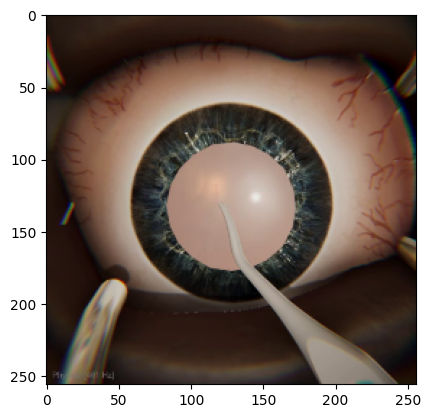

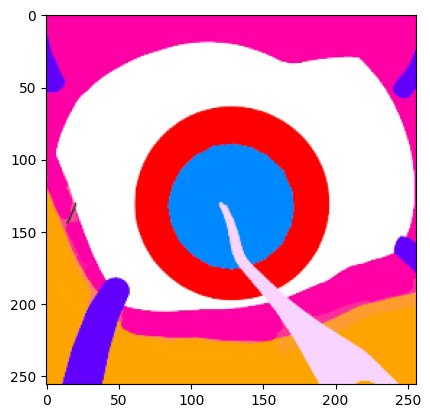

(256, 256) uint8
[0 1 2 3 4 5 6]
[21966 15332  9121  5554  8234  2583  2746]
0
(256, 256)
1
(256, 256)
2
(256, 256)
3
(256, 256)
4
(256, 256)
5
(256, 256)
6
(256, 256)


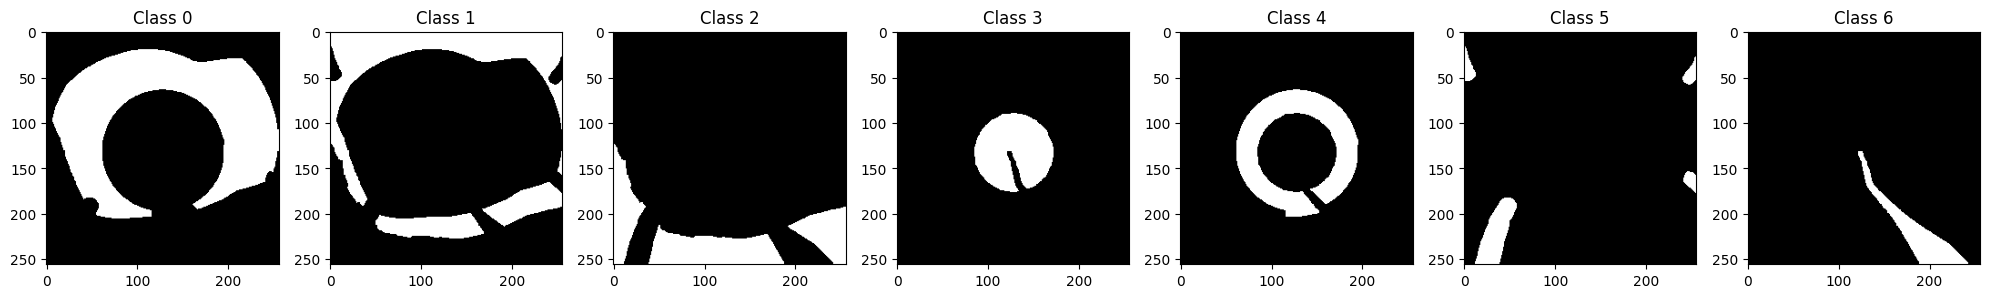

[0 3 4 5 6 8]
[21966  8234  2583 20886  9121  2746]
0
(256, 256)
3
(256, 256)
4
(256, 256)
5
(256, 256)
6
(256, 256)
8
(256, 256)


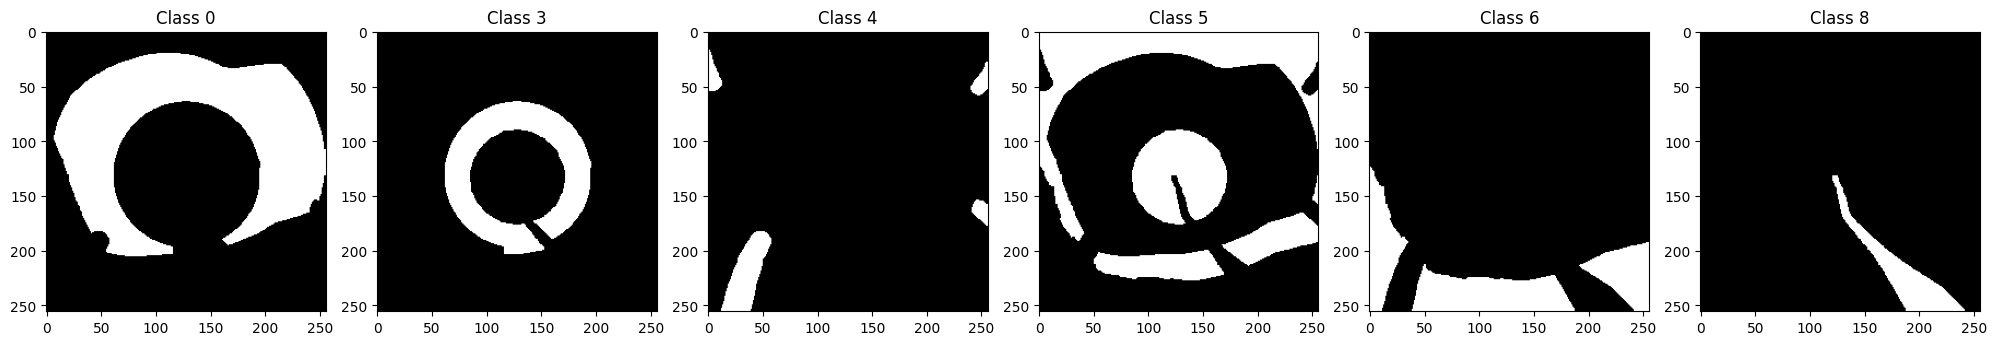

In [6]:

img1 = Image.open("records_cadis_1/records_single_files/r2/frame_0043.png")
img2 = Image.open("records_cadis_1/records_single_files/r2_processed/mask_0043_p.png")

img1 = np.asarray(img1)
img2 = np.asarray(img2)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


img1 = cv2.resize(img1, (256, 256), interpolation=cv2.INTER_LINEAR)
img2 = cv2.resize(img2, (256, 256), interpolation=cv2.INTER_LINEAR)


print(img2.shape, img2.dtype, np.min(img2), np.max(img2))


rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(img2, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)
print(img2[50,50])

# rgb_mask = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# rgb_mask = img2[:,:,0]
# rgb_mask = img2
# print(rgb_mask.shape, rgb_mask.dtype, np.min(rgb_mask), np.max(rgb_mask))



# rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(rgb_mask, return_counts=True)
# print(rgb_mask_unique_values)
# print(rgb_mask_unique_counts)
# print(rgb_mask[50,50])



plt.imshow(img1, cmap = "gray")
plt.show()


plt.imshow(img2, cmap = "gray")
plt.show()





lab = rgb2lab(img2)

segments = slic(img2, n_segments=300, compactness=10, start_label=0)

# Compute mean color per segment
segment_colors = []
for seg_id in np.unique(segments):
    segment_colors.append(lab[segments == seg_id].mean(axis=0))

segment_colors = np.array(segment_colors)

# Cluster segments
kmeans = KMeans(n_clusters=7, random_state=0)
seg_labels = kmeans.fit_predict(segment_colors)

# Build label map
label_map = np.zeros(segments.shape, dtype=np.int32)
for seg_id, lbl in enumerate(seg_labels):
    label_map[segments == seg_id] = lbl


kernel = np.ones((3,3), np.uint8)
label_map = cv2.morphologyEx(label_map.astype(np.uint8),
                          cv2.MORPH_OPEN, kernel)

print(label_map.shape, label_map.dtype)
rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(label_map, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)

seg_labels = rgb_mask_unique_values
fig, axes = plt.subplots(1, len(seg_labels),  figsize=(20, 7))


for i, cls_ in enumerate(seg_labels, start=0):
    print(cls_)
    # Create binary mask for this class
    binary_mask = np.where(label_map == cls_, 1, 0)
    print(binary_mask.shape)
    # print(np.unique(label_map, return_counts=True))

    # Show in subplot
    axes[i].imshow(binary_mask, cmap="gray")
    axes[i].set_title(f"Class {i}")
    # axes[i].axis("off")

plt.tight_layout()
plt.show()



out = przemek_to_cadis_fun(label_map)
rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(out, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)


seg_labels = rgb_mask_unique_values
fig, axes = plt.subplots(1, len(seg_labels),  figsize=(20, 7))

for i, cls_ in enumerate(seg_labels, start=0):
    print(cls_)
    # Create binary mask for this class
    binary_mask = np.where(out == cls_, 1, 0)
    print(binary_mask.shape)
    # print(np.unique(label_map, return_counts=True))

    # Show in subplot
    axes[i].imshow(binary_mask, cmap="gray")
    axes[i].set_title(f"Class {cls_}")
    # axes[i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
def to_one_hot(mask, num_classes=1):
    """
    mask: (H, W) uint8
    returns: (C, H, W) uint8
    """
    one_hot = np.zeros((num_classes, *mask.shape), dtype=np.uint8)
    one_hot[mask, np.arange(mask.shape[0])[:, None], np.arange(mask.shape[1])] = 1
    return one_hot

In [9]:
out.shape
print(np.unique(out, return_counts=1))

out_onehot = to_one_hot(out, 14)
print(out_onehot.shape)

print(np.unique(out_onehot[3], return_counts=1))


fig, axes = plt.subplots(1, len(np.unique(out)),  figsize=(20, 7))

for i, cls_ in enumerate(np.unique(out), start=0):
    # print(cls_)

    # Show in subplot
    axes[i].imshow(out_onehot[cls_], cmap="gray")
    axes[i].set_title(f"Class {cls_}")
    # axes[i].axis("off")

plt.tight_layout()
plt.show()

NameError: name 'out' is not defined

In [10]:
from train_controlnet_my import DatasetRetina, DatasetCADIS  # reuse your dataset definition


/home/MichalMo/anaconda3/envs/diffusers/lib/python3.1/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
dataset = DatasetCADIS(image_size=256, augment = False, augmentation_factor=0)




Index(['image_path', 'mask_path', 'text'], dtype='object')
                                          image_path  \
0  /home/MichalMo/projects/SurGrID/datasets/cadis...   
1  /home/MichalMo/projects/SurGrID/datasets/cadis...   
2  /home/MichalMo/projects/SurGrID/datasets/cadis...   

                                           mask_path          text  
0  /home/MichalMo/projects/SurGrID/datasets/cadis...  retina image  
1  /home/MichalMo/projects/SurGrID/datasets/cadis...  retina image  
2  /home/MichalMo/projects/SurGrID/datasets/cadis...  retina image  
Loaded 4670 samples, will virtually expand ×0 = 0


In [12]:
indices = [0,1,2]
samples = [dataset[i] for i in indices]
sample = samples[0]

cond = sample["mask"]  # [1,36,H,W]
print(cond.shape, cond.dtype)

prompt = sample["text"]
print(prompt)

torch.Size([36, 256, 256]) torch.float16
retina image


0
torch.Size([256, 256])


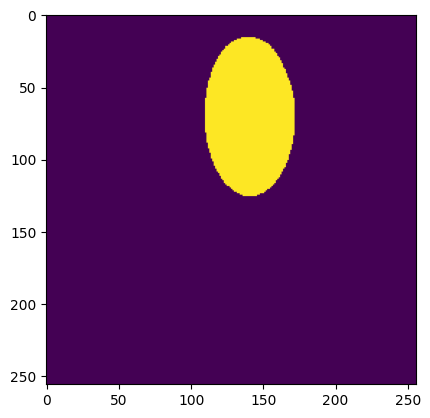

1
torch.Size([256, 256])


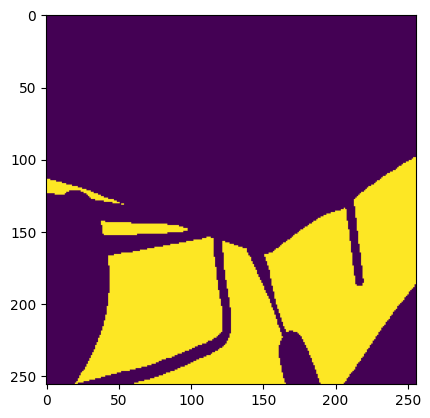

2
torch.Size([256, 256])


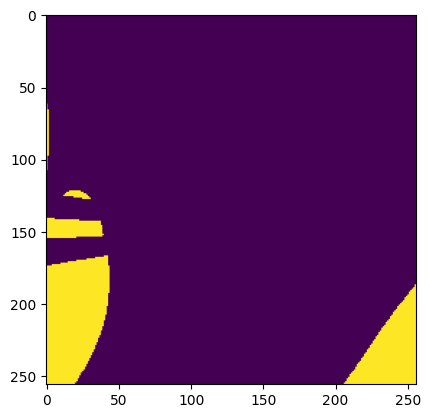

3
torch.Size([256, 256])


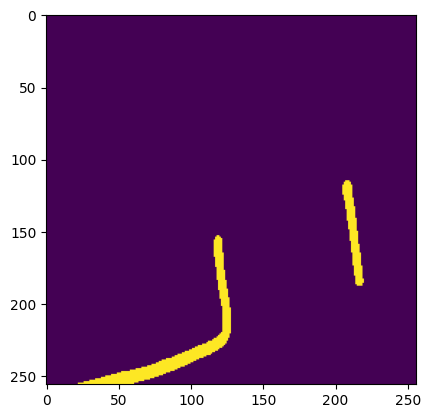

4
torch.Size([256, 256])


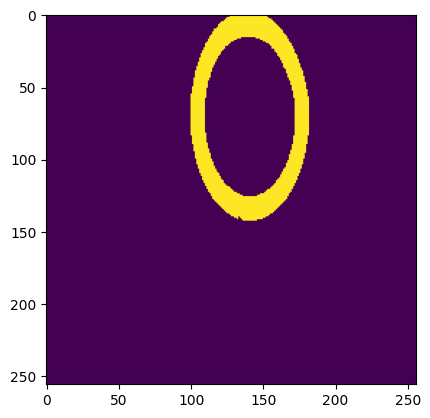

5
torch.Size([256, 256])


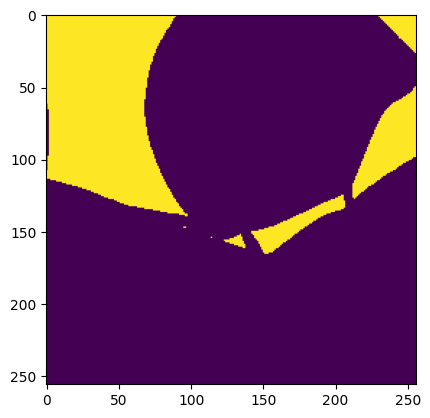

6
torch.Size([256, 256])


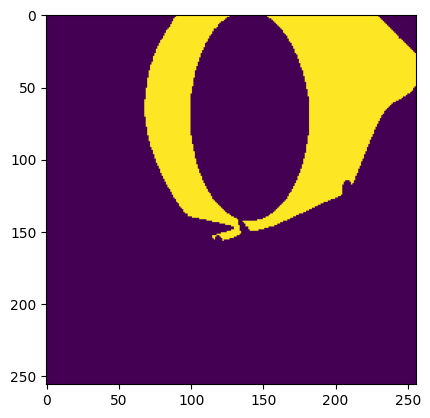

7
torch.Size([256, 256])


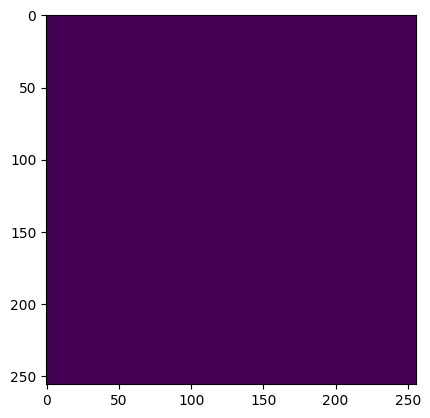

8
torch.Size([256, 256])


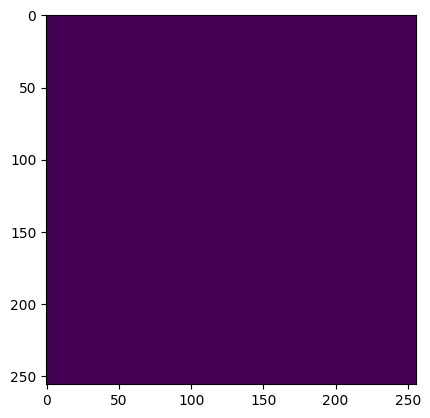

9
torch.Size([256, 256])


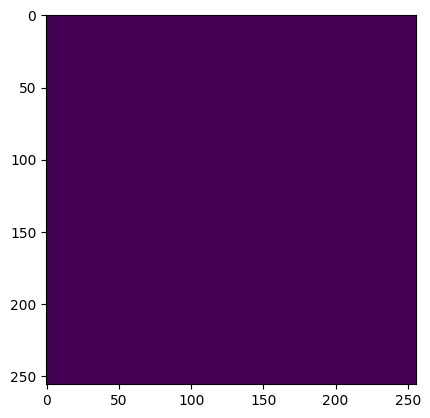

10
torch.Size([256, 256])


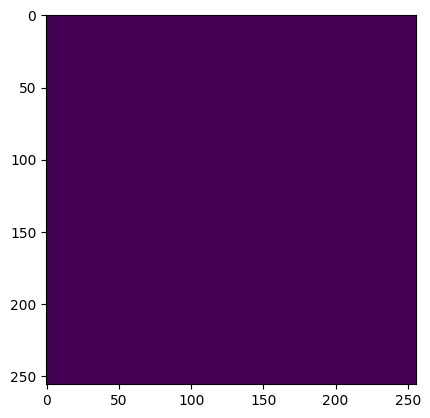

11
torch.Size([256, 256])


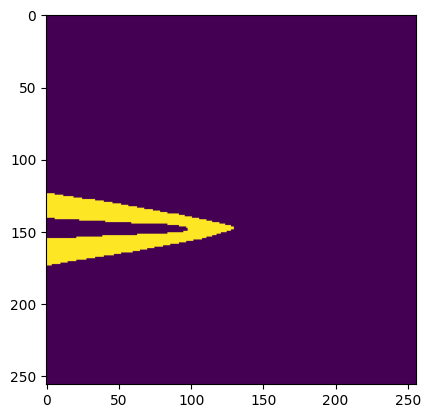

12
torch.Size([256, 256])


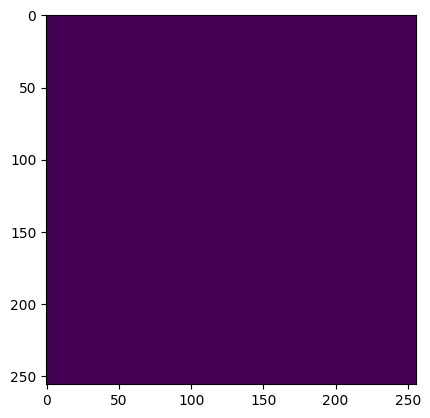

13
torch.Size([256, 256])


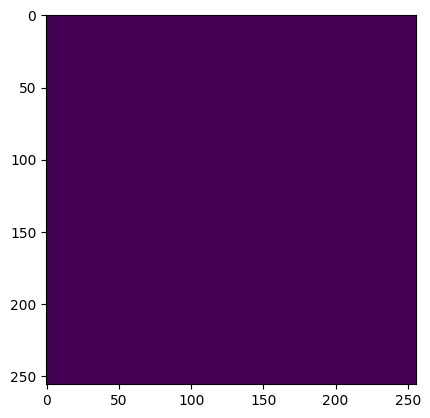

14
torch.Size([256, 256])


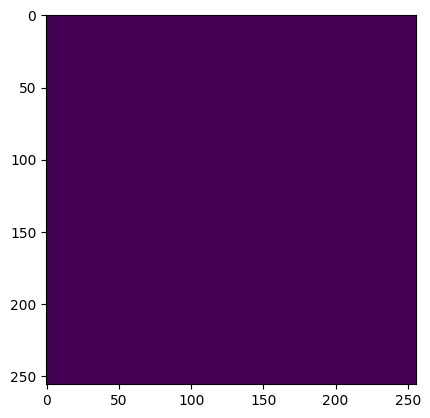

15
torch.Size([256, 256])


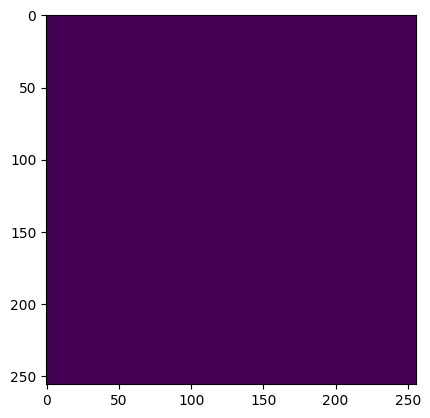

16
torch.Size([256, 256])


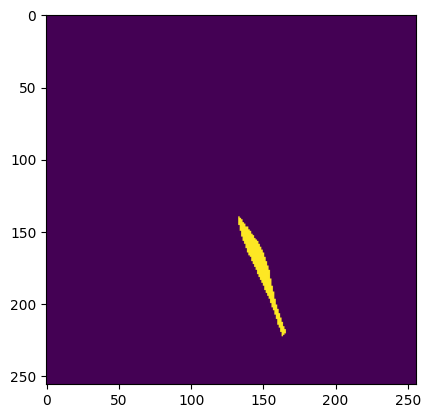

17
torch.Size([256, 256])


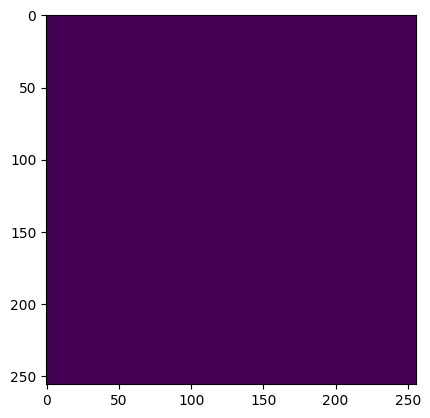

18
torch.Size([256, 256])


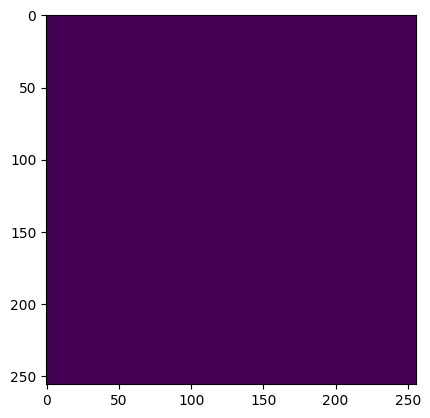

19
torch.Size([256, 256])


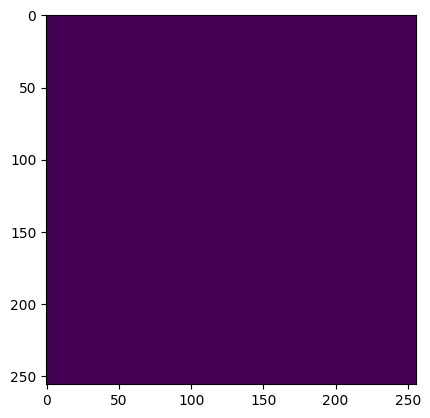

20
torch.Size([256, 256])


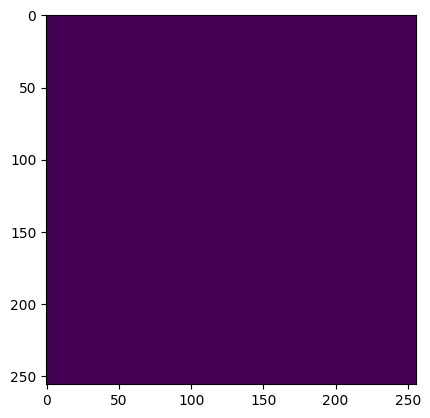

21
torch.Size([256, 256])


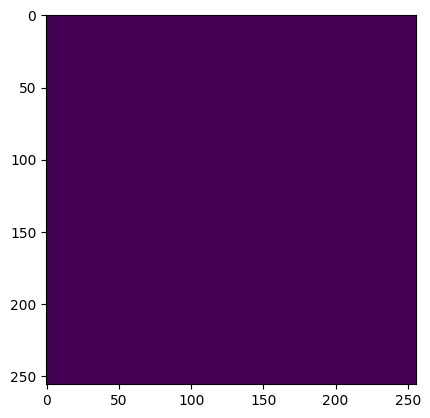

22
torch.Size([256, 256])


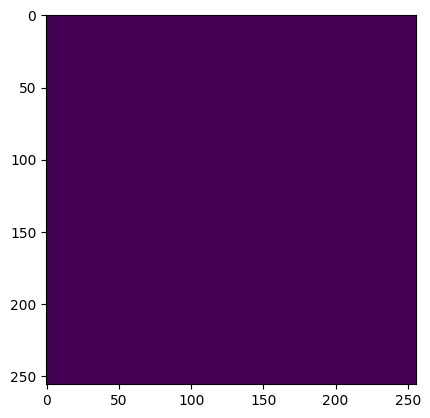

23
torch.Size([256, 256])


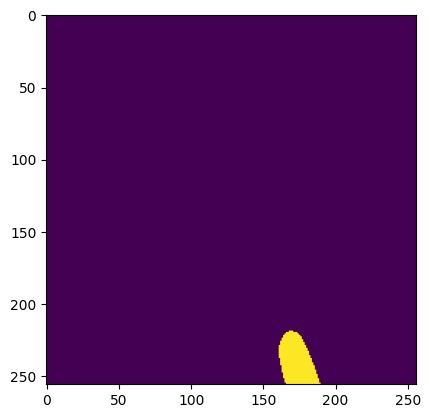

24
torch.Size([256, 256])


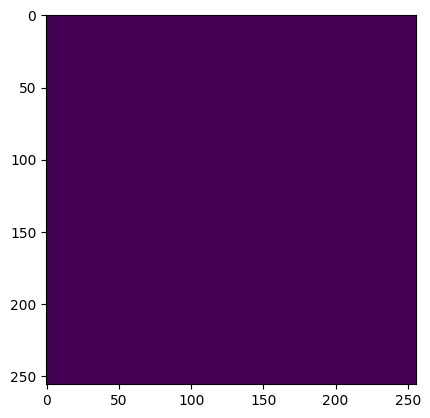

25
torch.Size([256, 256])


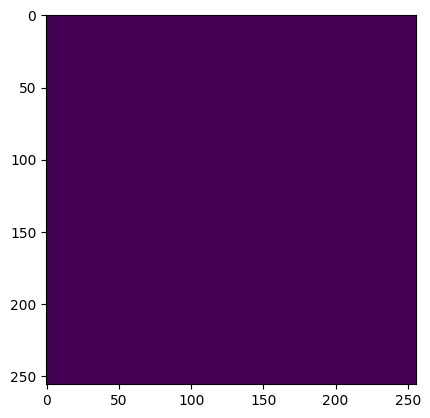

26
torch.Size([256, 256])


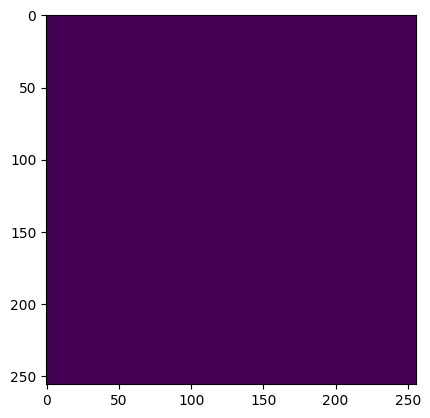

27
torch.Size([256, 256])


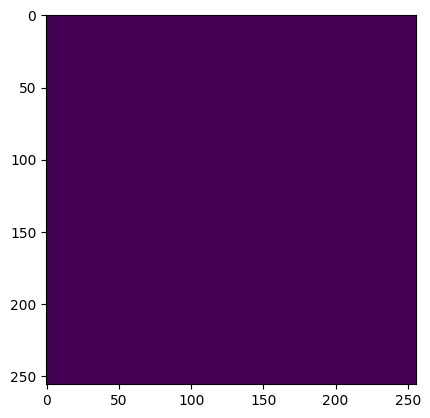

28
torch.Size([256, 256])


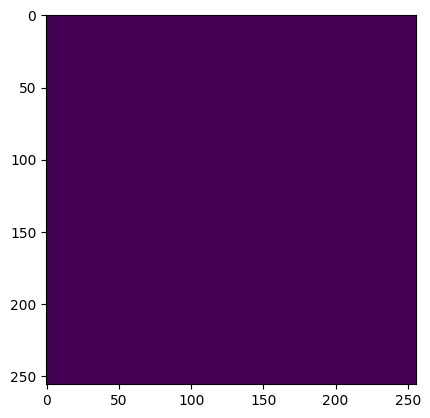

29
torch.Size([256, 256])


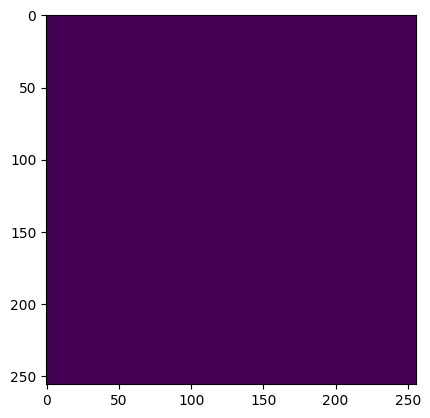

30
torch.Size([256, 256])


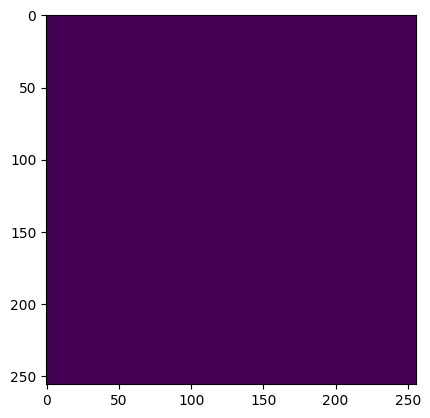

31
torch.Size([256, 256])


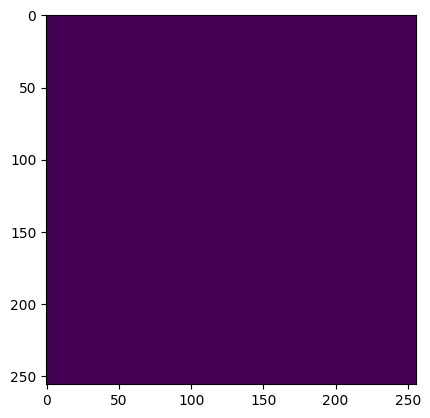

32
torch.Size([256, 256])


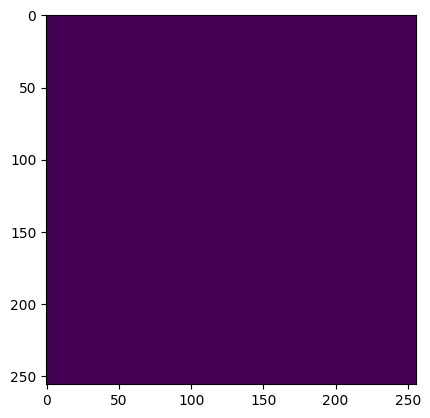

33
torch.Size([256, 256])


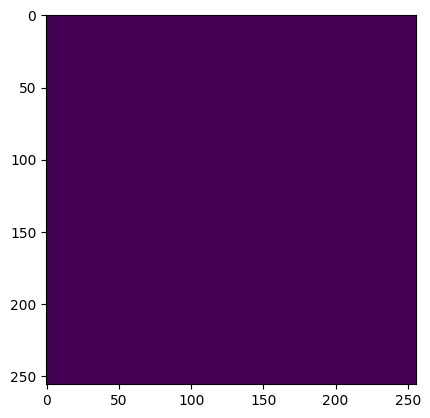

34
torch.Size([256, 256])


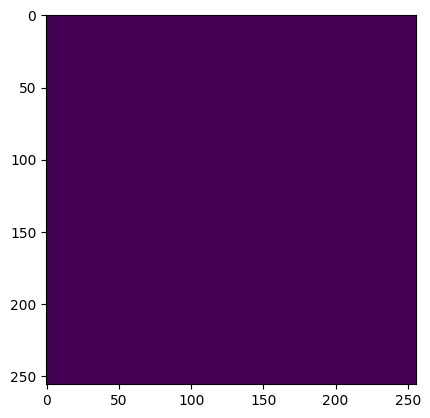

35
torch.Size([256, 256])


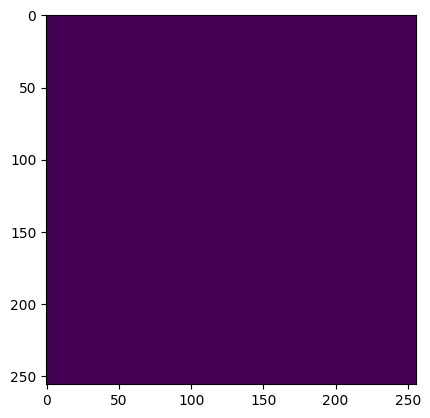

In [13]:
for i in range(0,36):
    print(i)

    img = cond[i,:,:]
    print(img.shape)

    plt.imshow(img)
    plt.show()

In [14]:
image = sample["image"].numpy().astype(np.float32)
image = image.transpose(1,2,0)
print(image.dtype)
image.shape

float32


(256, 256, 3)

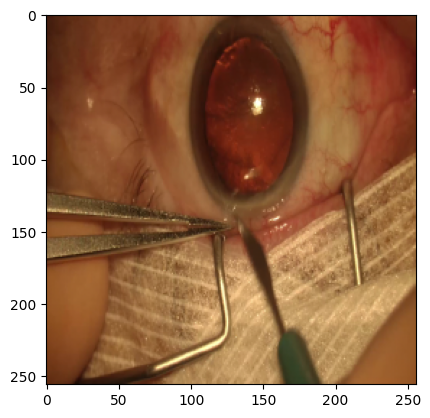

In [15]:
plt.imshow(image)

In [16]:

# coding=utf-8

import os
import torch
import random
import numpy as np
from tqdm import tqdm
from torchvision.utils import save_image
from transformers import CLIPTokenizer, CLIPTextModel
from diffusers import (
    AutoencoderKL,
    UNet2DConditionModel,
    ControlNetModel,
    DDPMScheduler,
)
from train_controlnet_my import DatasetRetina, DatasetCADIS  # reuse your dataset definition

from PIL import Image
import torch.nn.functional as F

import lpips

import pandas as pd
import cv2

import matplotlib.pyplot as plt

from torch.utils.data import Dataset

import torch_fidelity

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity




@torch.no_grad()
def evaluate_manual(
    out_onehot,
    checkpoint_path,
    pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5",
    output_dir="results/eval_manual",
    num_samples=0,
    num_inference_steps=30,
    device="cuda",
    image_size=256,
):
    """
    Evaluate ControlNet manually on segmentation-based conditioning (multi-channel).

    Args:
        checkpoint_path (str): Path to the trained ControlNet checkpoint folder (e.g., ".../checkpoint-200000/controlnet").
        pretrained_model_name_or_path (str): Stable Diffusion base model name or directory.
        output_dir (str): Directory where generated images will be saved.
        num_samples (int): Number of random samples from dataset to generate.
        num_inference_steps (int): Diffusion steps for generation.
        device (str): CUDA or CPU device.
        image_size (int): Image resolution (should match training).
    """


    # ---------------------------
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    print("[INFO] Loading pretrained components...")
    tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
    text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14").to(device, dtype=torch_dtype)
    vae = AutoencoderKL.from_pretrained(pretrained_model_name_or_path, subfolder="vae").to(device, dtype=torch_dtype)
    unet = UNet2DConditionModel.from_pretrained(pretrained_model_name_or_path, subfolder="unet").to(device, dtype=torch_dtype)
    controlnet = ControlNetModel.from_pretrained(checkpoint_path, torch_dtype=torch_dtype).to(device)

    noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name_or_path, subfolder="scheduler")

    vae.eval()
    unet.eval()
    controlnet.eval()
    text_encoder.eval()

    print(vae.config.scaling_factor)
# 

    # ---------------------------
    # 3️⃣ Diffusion sampling loop
    # ---------------------------


    # cond = sample["mask"].unsqueeze(0).to(device, dtype=torch_dtype)  # [1,14,H,W]
    cond = torch.tensor(out_onehot.astype(np.float16)).unsqueeze(0).to(device)
    print(cond.shape, cond.dtype)

    # print(sample["file_name"])

    # Tokenize prompt → CLIP hidden states
    text_inputs = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    ).to(device)
    encoder_hidden_states = text_encoder(text_inputs.input_ids)[0]  # [1,77,768]

    # Initialize random latent (the "image" in latent space)
    latents = torch.randn(
        (1, unet.in_channels, image_size // 8, image_size // 8),
        device=device,
        dtype=torch_dtype,
    )

    # Prepare scheduler
    noise_scheduler.set_timesteps(num_inference_steps)
    # print(f"[INFO] Sampling with {num_inference_steps} steps...")

    for t in tqdm(noise_scheduler.timesteps, desc=f"Sample {+1}/{num_samples}"):
        # Predict noise using ControlNet + UNet
        down_block_res_samples, mid_block_res_sample = controlnet(
            latents,
            t,
            encoder_hidden_states=encoder_hidden_states,
            controlnet_cond=cond,
            return_dict=False,
        )

        noise_pred = unet(
            latents,
            t,
            encoder_hidden_states=encoder_hidden_states,
            down_block_additional_residuals=[
                sample.to(dtype=torch_dtype) for sample in down_block_res_samples
            ],
            mid_block_additional_residual=mid_block_res_sample.to(dtype=torch_dtype),
            return_dict=False,
        )[0]

        # Step with scheduler
        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    # ---------------------------
    # 4️⃣ Decode latents → image
    # ---------------------------
    latents = 1 / vae.config.scaling_factor * latents
    image_decoded = vae.decode(latents).sample  # [1,3,H,W]

    # print(image_decoded.shape, image_decoded.dtype, torch.min(image_decoded), torch.max(image_decoded))

    # Map from [-1,1] → [0,1]
    # image = (image.clamp(-1, 1) + 1) / 2.0
    image = (image_decoded / 2 + 0.5).clamp(0, 1)
    # print(image.shape, image.dtype, torch.min(image), torch.max(image))

    image = image.float()

    # print(image.shape, image.dtype, torch.min(image), torch.max(image))
    image = (image - image.min()) / (image.max() - image.min() + 1e-5)
    # print(image.shape, image.dtype, torch.min(image), torch.max(image))

    # # Save result
    # save_path = os.path.join(output_dir, f"sample_{0:03d}.png")
    # # save_image(image.cpu(), save_path)



    # # Convert to grayscale (class indices)
    # grayscale_mask = np.argmax(cond.cpu().numpy()[0], axis=0).astype(np.uint8)  # shape [256, 256]

    # # Optional: add channel dimension
    # grayscale_mask = np.expand_dims(grayscale_mask, axis=-1)  # shape [256, 256, 1]

    # # print(grayscale_mask.shape)  # (256, 256, 1)
    # # print(grayscale_mask.min(), grayscale_mask.max())  # 0 13

    # img = Image.fromarray(grayscale_mask.astype(np.uint8)[:,:,0], mode = "L")

    # save_path_cond = os.path.join(output_dir, f"sample_{0:03d}_cond.png")
    # # save_image(grayscale_mask, save_path_cond)

    # # img.save(save_path_cond)


    # #################################################################

    # # save org image

    # img_org = (sample["image"].cpu().numpy().transpose(1,2,0)*255.0).astype(np.uint8)
    # # print(img_org.shape, img_org.dtype, np.min(img_org), np.max(img_org))
    # img_org_pil = Image.fromarray(img_org)

    # save_path_org_image = os.path.join(output_dir, f"sample_{0:03d}_org.png")
    # # img_org_pil.save(save_path_org_image)




    # # Metrics

    # image_m = image.squeeze(0).permute(1, 2, 0).cpu() # torch [256,256,3] float32 [0-1]

    # img_org2 = torch.tensor(img_org).cpu().to(dtype=torch.float32)/255.0 # torch [256,256,3] float32 [0-1]
    # # print("METRICS")
    # # print(image_m.shape, image_m.dtype, torch.min(image_m), torch.max(image_m))

    # # print(img_org2.shape, img_org2.dtype, torch.min(img_org2), torch.max(img_org2))





    return image






In [16]:
out_image = evaluate_manual(
    out_onehot,
    # checkpoint_path="/home/MichalMo/projects/ControlNet-diffusers/cadis_2/checkpoint-70056/controlnet",
    checkpoint_path="/home/MichalMo/projects/ControlNet-diffusers/cataract_mysplit_1/checkpoint-121260/controlnet",

    output_dir="",
    num_samples=1,
    num_inference_steps=100,
    image_size=256,
)




[INFO] Loading pretrained components...
0.18215
torch.Size([1, 14, 256, 256]) torch.float16


/tmp/ipykernel_3009139/3716262141.py:106: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, unet.in_channels, image_size // 8, image_size // 8),
Sample 1/1: 100%|██████████| 100/100 [00:07<00:00, 13.69it/s]


In [18]:
out_image.shape

torch.Size([1, 3, 256, 256])

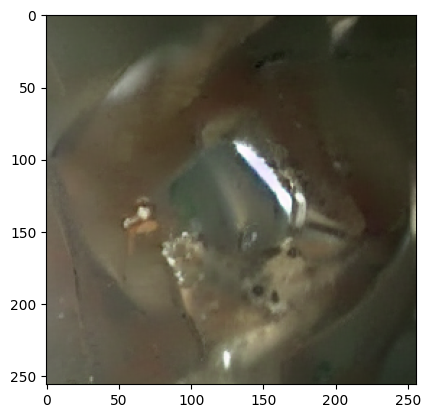

In [19]:
plt.subplot(131)

plt.imshow(image)

plt.subplot(132)



plt.subplot(133)

plt.imshow(out_image[0].cpu().numpy().transpose(1,2,0))

# Przemek to RETINA ( cataract 1k)


# 0 - 0
# 1 - 5
# 2 - 4
# 3 - 5
# 4 - 3
# 5 - 6
# 6 - 15

In [18]:
przemek_to_cataract_map = {
    0:0,
    1:0, 
    2:0,
    3:2,
    4:1,
    5:0,
    6:5
}


cataract_to_przemek_map = dict((v,k) for k,v in przemek_to_cataract_map.items())
print(cataract_to_przemek_map)

def przemek_to_cataract_fun(input):


    input = input.astype(np.uint8)

    output = np.arange(256, dtype=np.uint8)
    for k, v in przemek_to_cataract_map.items():
        output[k] = v
    return output[input]



dataset = DatasetRetina(image_size=256, augment = False, augmentation_factor=1, 
                                from_file=['/home/MichalMo/projects/ControlNet-diffusers/cataract_my_split_1/cataract_my_split_1_val.csv'])


samples = [dataset[i] for i in [100]]
indices = [0,1,2]
samples = [dataset[i] for i in indices]
sample = samples[0]

cond = sample["mask"]  # [1,36,H,W]
print(cond.shape, cond.dtype)

prompt = sample["text"]
print(prompt)



{0: 5, 2: 3, 1: 4, 5: 6}
(169, 4)
Loaded 169 samples, will virtually expand ×1 = 169
torch.Size([14, 256, 256]) torch.float16
retina image


(256, 256, 3) uint8 0 255
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 

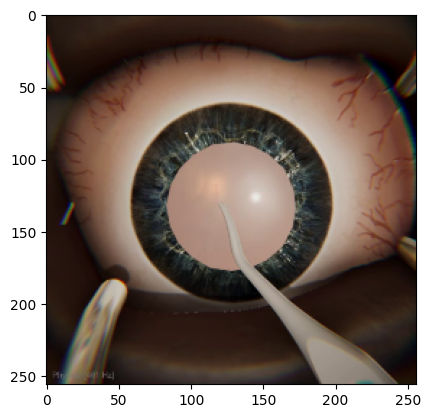

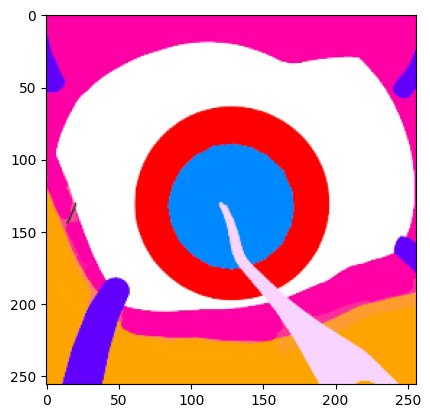

(256, 256) uint8
[0 1 2 3 4 5 6]
[21966 15332  9121  5554  8234  2583  2746]
0
(256, 256)
1
(256, 256)
2
(256, 256)
3
(256, 256)
4
(256, 256)
5
(256, 256)
6
(256, 256)


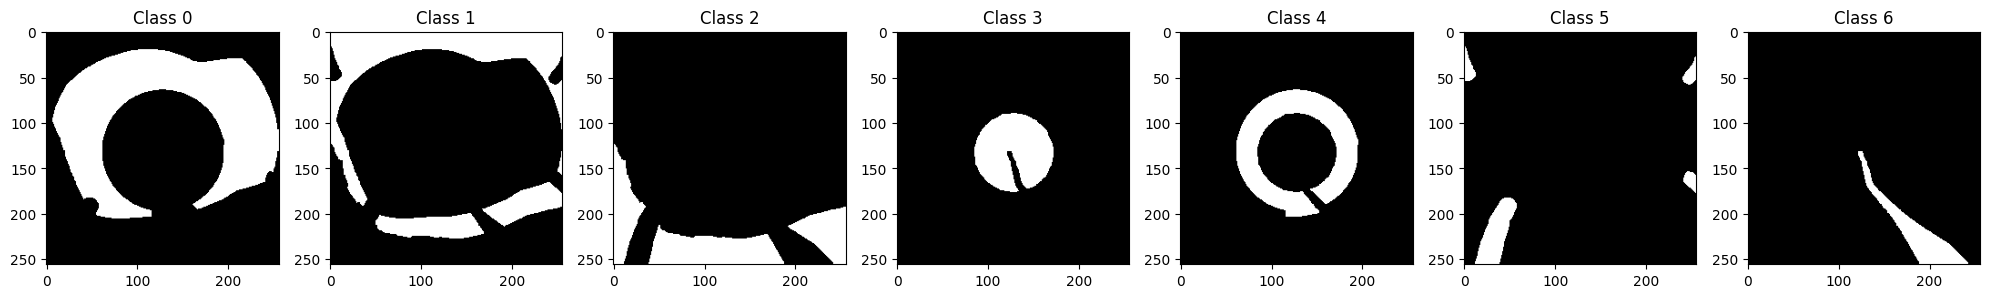

[0 1 2 5]
[49002  8234  5554  2746]
0
(256, 256)
1
(256, 256)
2
(256, 256)
5
(256, 256)


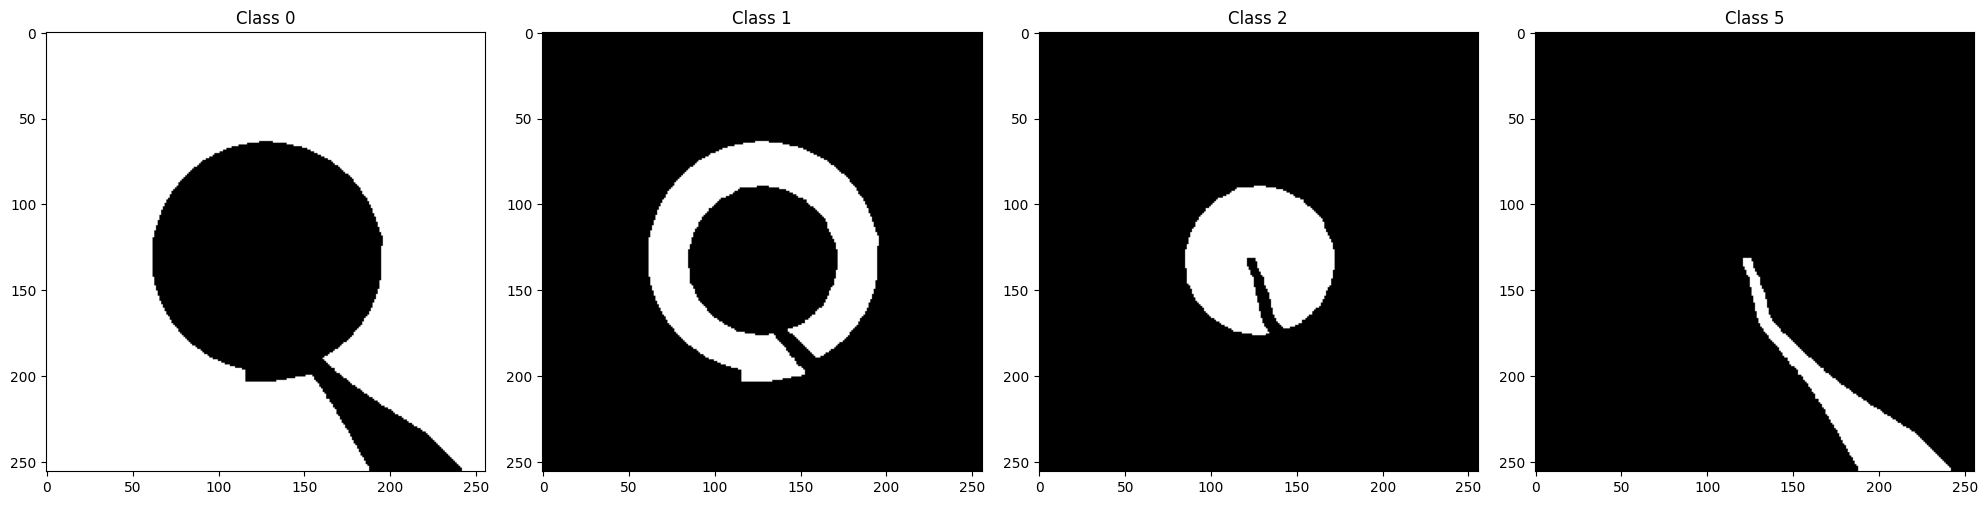

In [19]:
img1 = Image.open("records_cadis_1/records_single_files/r2/frame_0043.png")
img2 = Image.open("records_cadis_1/records_single_files/r2_processed/mask_0043_p.png")

img1 = np.asarray(img1)
img2 = np.asarray(img2)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


img1 = cv2.resize(img1, (256, 256), interpolation=cv2.INTER_LINEAR)
img2 = cv2.resize(img2, (256, 256), interpolation=cv2.INTER_LINEAR)


print(img2.shape, img2.dtype, np.min(img2), np.max(img2))


rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(img2, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)
print(img2[50,50])


plt.imshow(img1, cmap = "gray")
plt.show()


plt.imshow(img2, cmap = "gray")
plt.show()





lab = rgb2lab(img2)

segments = slic(img2, n_segments=300, compactness=10, start_label=0)

# Compute mean color per segment
segment_colors = []
for seg_id in np.unique(segments):
    segment_colors.append(lab[segments == seg_id].mean(axis=0))

segment_colors = np.array(segment_colors)

# Cluster segments
kmeans = KMeans(n_clusters=7, random_state=0)
seg_labels = kmeans.fit_predict(segment_colors)

# Build label map
label_map = np.zeros(segments.shape, dtype=np.int32)
for seg_id, lbl in enumerate(seg_labels):
    label_map[segments == seg_id] = lbl


kernel = np.ones((3,3), np.uint8)
label_map = cv2.morphologyEx(label_map.astype(np.uint8),
                          cv2.MORPH_OPEN, kernel)

print(label_map.shape, label_map.dtype)
rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(label_map, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)

seg_labels = rgb_mask_unique_values
fig, axes = plt.subplots(1, len(seg_labels),  figsize=(20, 7))


for i, cls_ in enumerate(seg_labels, start=0):
    print(cls_)
    # Create binary mask for this class
    binary_mask = np.where(label_map == cls_, 1, 0)
    print(binary_mask.shape)
    # print(np.unique(label_map, return_counts=True))

    # Show in subplot
    axes[i].imshow(binary_mask, cmap="gray")
    axes[i].set_title(f"Class {i}")
    # axes[i].axis("off")

plt.tight_layout()
plt.show()



out = przemek_to_cataract_fun(label_map)
rgb_mask_unique_values, rgb_mask_unique_counts = np.unique(out, return_counts=True)
print(rgb_mask_unique_values)
print(rgb_mask_unique_counts)


seg_labels = rgb_mask_unique_values
fig, axes = plt.subplots(1, len(seg_labels),  figsize=(20, 7))

for i, cls_ in enumerate(seg_labels, start=0):
    print(cls_)
    # Create binary mask for this class
    binary_mask = np.where(out == cls_, 1, 0)
    print(binary_mask.shape)
    # print(np.unique(label_map, return_counts=True))

    # Show in subplot
    axes[i].imshow(binary_mask, cmap="gray")
    axes[i].set_title(f"Class {cls_}")
    # axes[i].axis("off")

plt.tight_layout()
plt.show()

(array([0, 1, 2, 5], dtype=uint8), array([49002,  8234,  5554,  2746]))
(14, 256, 256)
(array([0], dtype=uint8), array([65536]))


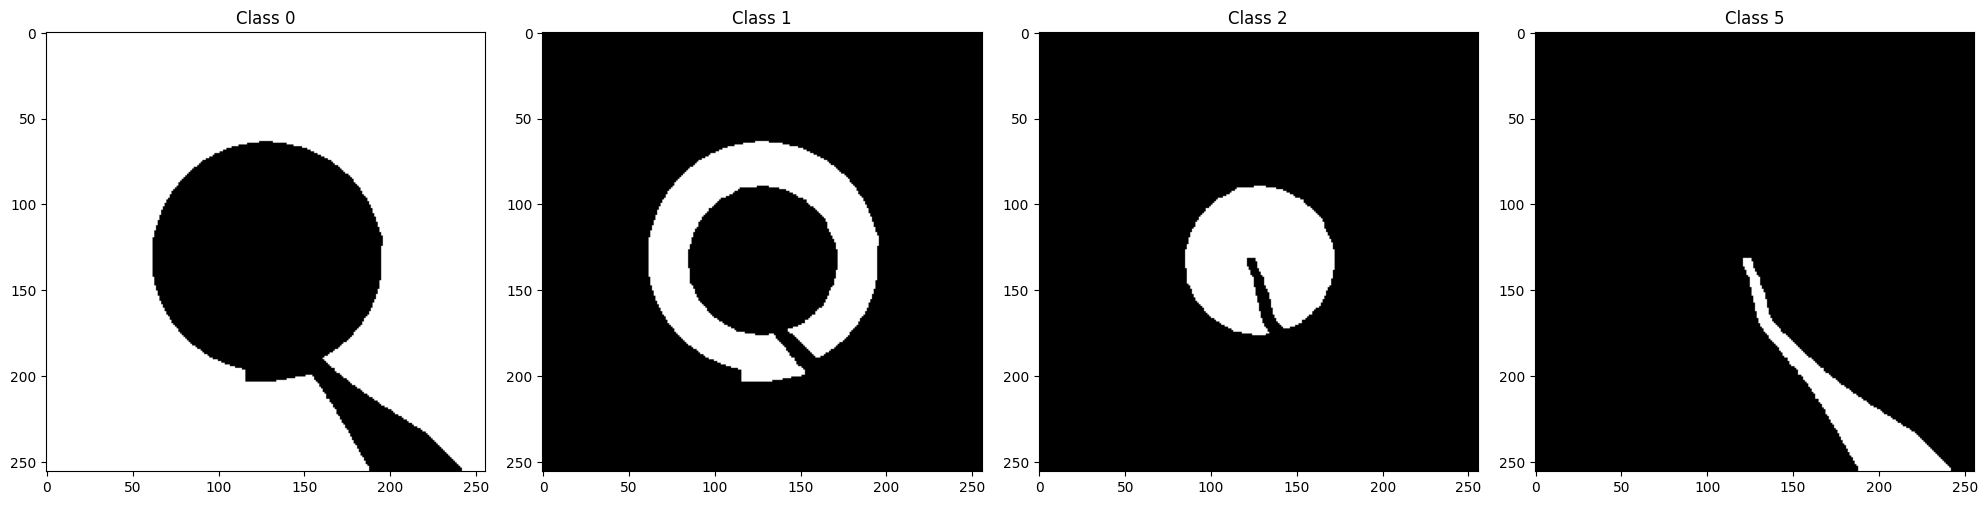

In [21]:
out.shape
print(np.unique(out, return_counts=1))

out_onehot = to_one_hot(out, 14)
print(out_onehot.shape)

print(np.unique(out_onehot[3], return_counts=1))


fig, axes = plt.subplots(1, len(np.unique(out)),  figsize=(20, 7))

for i, cls_ in enumerate(np.unique(out), start=0):
    # print(cls_)

    # Show in subplot
    axes[i].imshow(out_onehot[cls_], cmap="gray")
    axes[i].set_title(f"Class {cls_}")
    # axes[i].axis("off")

plt.tight_layout()
plt.show()

In [22]:
out_onehot.shape

(14, 256, 256)

In [23]:
out_image = evaluate_manual(
    out_onehot,
    # checkpoint_path="/home/MichalMo/projects/ControlNet-diffusers/cadis_2/checkpoint-70056/controlnet",
    checkpoint_path="/home/MichalMo/projects/ControlNet-diffusers/cataract_mysplit_1/checkpoint-121260/controlnet",

    output_dir="",
    num_samples=1,
    num_inference_steps=100,
    image_size=256,
)


[INFO] Loading pretrained components...
0.18215
torch.Size([1, 14, 256, 256]) torch.float16


/tmp/ipykernel_3536357/489436487.py:107: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, unet.in_channels, image_size // 8, image_size // 8),
Sample 1/1: 100%|██████████| 100/100 [00:07<00:00, 12.98it/s]


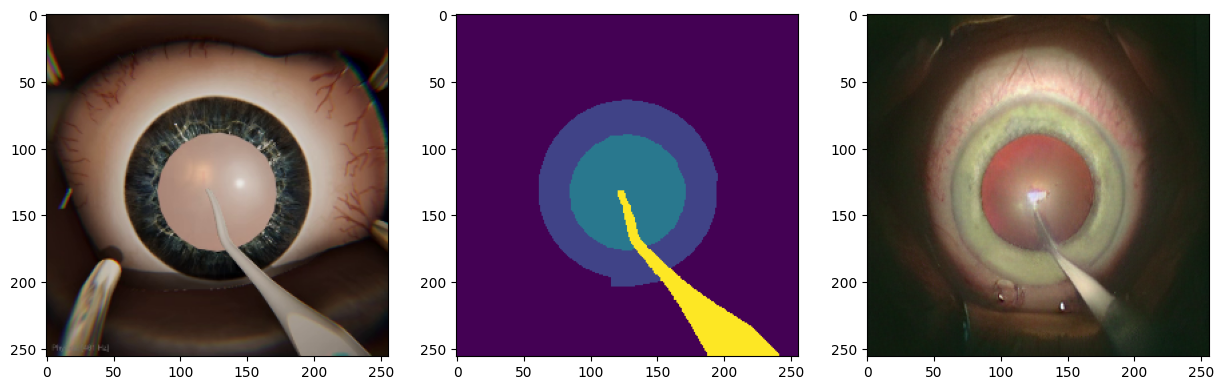

In [24]:
plt.figure(figsize=(15,5))

plt.subplot(131)

plt.imshow(img1)

plt.subplot(132)


plt.imshow(out)

plt.subplot(133)

plt.imshow(out_image[0].cpu().numpy().transpose(1,2,0))